# 第三课：线性回归 —— 从零实现 vs nn.Module 实现

## 什么是线性回归？

线性回归是最基础的机器学习模型：

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

目标：找到最优的 $\mathbf{w}$ 和 $b$，使得预测值 $\hat{y}$ 尽可能接近真实值 $y$。

## 本课内容

| 部分 | 方式 | 特点 |
|------|------|------|
| 方法一 | 从零实现 | 手动定义参数、前向传播、损失、梯度更新 |
| 方法二 | nn.Module | 用 PyTorch 的线性层，更优雅、更工程化 |

In [1]:
import torch
import matplotlib.pyplot as plt

## 1. 生成模拟数据

我们生成一个一维线性关系的数据集：$y = 2x + 1 + \epsilon$

数据形状: X=torch.Size([200, 1]), y=torch.Size([200, 1])
真实参数: w=2.0, b=1.0


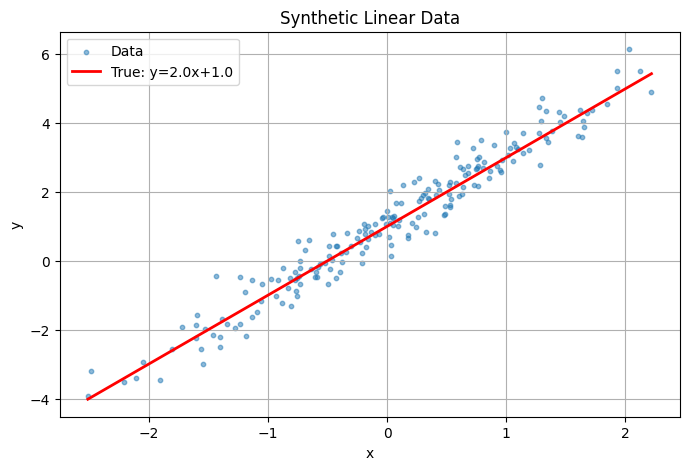

In [2]:
torch.manual_seed(42)

# 真实参数
true_w = 2.0
true_b = 1.0

# 生成数据
n_samples = 200
X = torch.randn(n_samples, 1)
noise = 0.5 * torch.randn(n_samples, 1)
y = true_w * X + true_b + noise

print(f"数据形状: X={X.shape}, y={y.shape}")
print(f"真实参数: w={true_w}, b={true_b}")

# 可视化
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.5, label='Data')
x_line = torch.linspace(X.min(), X.max(), 100).unsqueeze(1)
plt.plot(x_line.numpy(), (true_w * x_line + true_b).numpy(), 'r-', linewidth=2, label=f'True: y={true_w}x+{true_b}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Linear Data')
plt.legend()
plt.grid(True)
plt.show()

---
## 方法一：从零实现（手动定义一切）

我们需要手动完成以下步骤：
1. 初始化参数 $w, b$
2. 定义前向传播 $\hat{y} = wx + b$
3. 定义损失函数 $L = \frac{1}{n}\sum(\hat{y}_i - y_i)^2$
4. 反向传播求梯度
5. 更新参数 $w \leftarrow w - \eta \frac{\partial L}{\partial w}$

In [3]:
# 1. 初始化参数
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
print(f"初始参数: w={w.item():.4f}, b={b.item():.4f}")

# 超参数
lr = 0.1
epochs = 100

# 记录训练过程
losses = []
w_history = []
b_history = []

初始参数: w=-1.6004, b=0.8984


In [4]:
# 2. 训练循环
for epoch in range(epochs):
    # 前向传播：y_pred = w * X + b
    y_pred = w * X + b
    
    # 计算损失：MSE
    loss = ((y_pred - y) ** 2).mean()
    
    # 反向传播
    loss.backward()
    
    # 记录
    losses.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())
    
    # 更新参数（梯度下降）
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        
        # 清零梯度！
        w.grad.zero_()
        b.grad.zero_()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.6f}, w={w.item():.4f}, b={b.item():.4f}")

print(f"\n最终参数: w={w.item():.4f}, b={b.item():.4f}")
print(f"真实参数: w={true_w}, b={true_b}")

Epoch  20: loss=0.211279, w=1.9731, b=1.0732
Epoch  40: loss=0.207403, w=2.0234, b=1.0648
Epoch  60: loss=0.207402, w=2.0242, b=1.0646
Epoch  80: loss=0.207402, w=2.0242, b=1.0646
Epoch 100: loss=0.207402, w=2.0242, b=1.0646

最终参数: w=2.0242, b=1.0646
真实参数: w=2.0, b=1.0


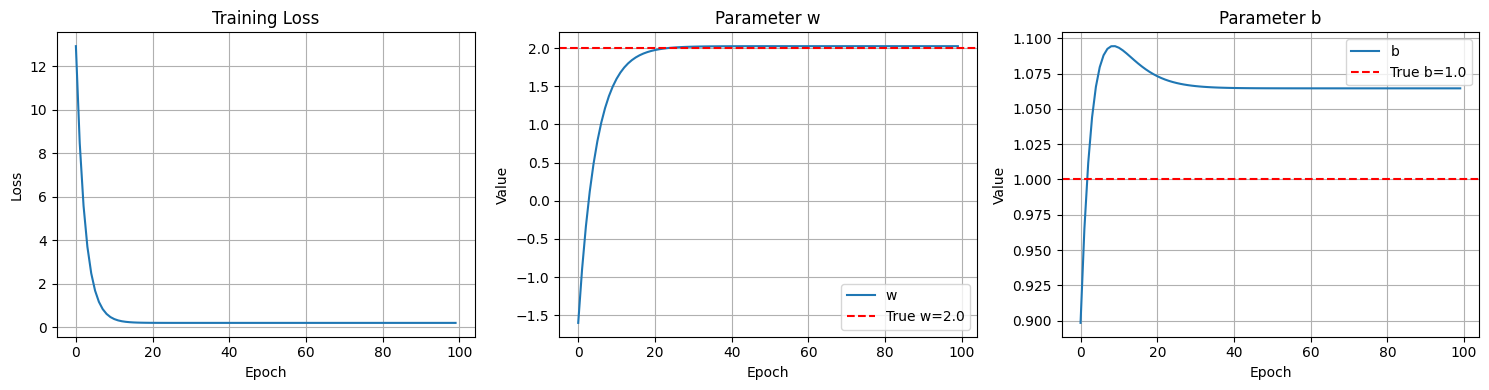

In [5]:
# 可视化训练过程
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 损失曲线
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# 参数收敛过程
axes[1].plot(w_history, label='w')
axes[1].axhline(y=true_w, color='r', linestyle='--', label=f'True w={true_w}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Value')
axes[1].set_title('Parameter w')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(b_history, label='b')
axes[2].axhline(y=true_b, color='r', linestyle='--', label=f'True b={true_b}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Value')
axes[2].set_title('Parameter b')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

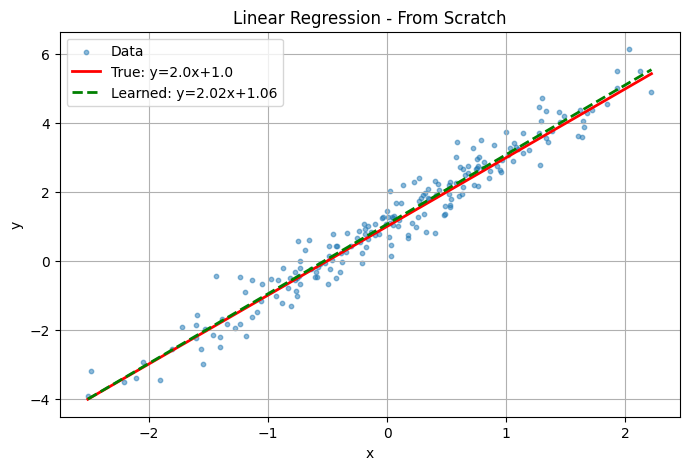

In [6]:
# 拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.5, label='Data')
x_line = torch.linspace(X.min(), X.max(), 100).unsqueeze(1)
y_true_line = true_w * x_line + true_b
y_pred_line = w.detach() * x_line + b.detach()
plt.plot(x_line.numpy(), y_true_line.numpy(), 'r-', linewidth=2, label=f'True: y={true_w}x+{true_b}')
plt.plot(x_line.numpy(), y_pred_line.numpy(), 'g--', linewidth=2, label=f'Learned: y={w.item():.2f}x+{b.item():.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression - From Scratch')
plt.legend()
plt.grid(True)
plt.show()

---
## 方法二：使用 nn.Module（PyTorch 标准方式）

PyTorch 提供了 `nn.Module` 来更优雅地定义模型，以及 `nn.MSELoss`、`optim.SGD` 等工具。

### nn.Module 的核心组件

| 组件 | 作用 |
|------|------|
| `nn.Linear(in, out)` | 全连接层，自动管理 w 和 b |
| `nn.MSELoss()` | 均方误差损失 |
| `optim.SGD(params, lr)` | 随机梯度下降优化器 |
| `model.parameters()` | 获取所有可学习参数 |

In [7]:
import torch.nn as nn
import torch.optim as optim

# 1. 定义模型
model = nn.Linear(in_features=1, out_features=1)  # 一维输入 → 一维输出

print("模型结构:", model)
print("模型参数:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, value={param.data.numpy().flatten()}")

# nn.Linear 自动创建了 weight 和 bias
# weight 对应 w，bias 对应 b

模型结构: Linear(in_features=1, out_features=1, bias=True)
模型参数:
  weight: shape=torch.Size([1, 1]), value=[-0.38795483]
  bias: shape=torch.Size([1]), value=[0.0153054]


In [8]:
# 2. 定义损失函数和优化器
criterion = nn.MSELoss()                    # 损失函数
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 优化器

print(f"损失函数: {criterion}")
print(f"优化器: {optimizer}")

损失函数: MSELoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [9]:
# 3. 训练循环
nn_losses = []

for epoch in range(100):
    # 前向传播
    y_pred = model(X)            # model 本身就是可调用的！
    loss = criterion(y_pred, y)  # 计算损失
    
    # 反向传播
    optimizer.zero_grad()  # 清零梯度（替代手动 zero_()）
    loss.backward()        # 计算梯度
    optimizer.step()       # 更新参数（替代手动 w -= lr * w.grad）
    
    nn_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        w_val = model.weight.item()
        b_val = model.bias.item()
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.6f}, w={w_val:.4f}, b={b_val:.4f}")

w_val = model.weight.item()
b_val = model.bias.item()
print(f"\n最终参数: w={w_val:.4f}, b={b_val:.4f}")
print(f"真实参数: w={true_w}, b={true_b}")

Epoch  20: loss=0.208925, w=1.9929, b=1.0592
Epoch  40: loss=0.207402, w=2.0237, b=1.0646
Epoch  60: loss=0.207402, w=2.0242, b=1.0646
Epoch  80: loss=0.207402, w=2.0242, b=1.0646
Epoch 100: loss=0.207402, w=2.0242, b=1.0646

最终参数: w=2.0242, b=1.0646
真实参数: w=2.0, b=1.0


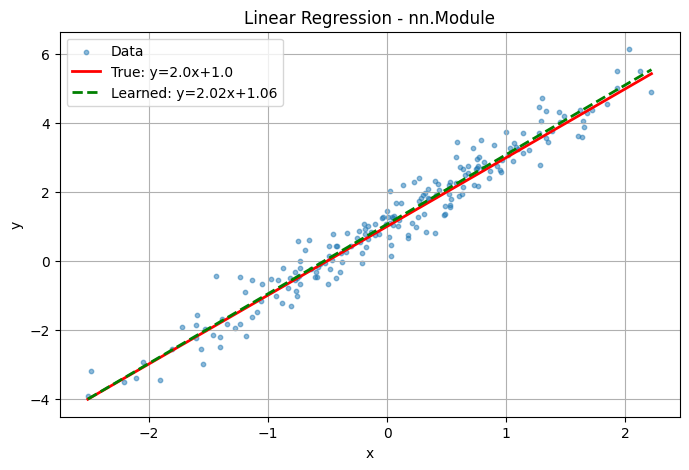

In [10]:
# 拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.5, label='Data')
x_line = torch.linspace(X.min(), X.max(), 100).unsqueeze(1)
with torch.no_grad():
    y_nn_line = model(x_line)
plt.plot(x_line.numpy(), (true_w * x_line + true_b).numpy(), 'r-', linewidth=2, label=f'True: y={true_w}x+{true_b}')
plt.plot(x_line.numpy(), y_nn_line.numpy(), 'g--', linewidth=2, label=f'Learned: y={w_val:.2f}x+{b_val:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression - nn.Module')
plt.legend()
plt.grid(True)
plt.show()

---
## 方法三：自定义 nn.Module 子类（最常用方式）

当模型变复杂时，我们需要自定义 `nn.Module` 子类。这是实际项目中最常用的方式。

In [11]:
class LinearRegressionModel(nn.Module):
    """自定义线性回归模型"""
    
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 定义层
    
    def forward(self, x):
        return self.linear(x)          # 定义前向传播

# 创建模型实例
model_custom = LinearRegressionModel()

print("自定义模型:")
print(model_custom)
print("\n模型参数:")
for name, param in model_custom.named_parameters():
    print(f"  {name}: {param.data.numpy().flatten()}")

自定义模型:
LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

模型参数:
  linear.weight: [-0.19761586]
  linear.bias: [0.12123895]


In [12]:
# 训练自定义模型
criterion = nn.MSELoss()
optimizer = optim.SGD(model_custom.parameters(), lr=0.1)

custom_losses = []

for epoch in range(100):
    y_pred = model_custom(X)
    loss = criterion(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    custom_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.6f}")

w_val = model_custom.linear.weight.item()
b_val = model_custom.linear.bias.item()
print(f"\n最终参数: w={w_val:.4f}, b={b_val:.4f}")
print(f"真实参数: w={true_w}, b={true_b}")

Epoch  20: loss=0.208694
Epoch  40: loss=0.207402
Epoch  60: loss=0.207402
Epoch  80: loss=0.207402
Epoch 100: loss=0.207402

最终参数: w=2.0242, b=1.0646
真实参数: w=2.0, b=1.0


---
## 三种方式对比

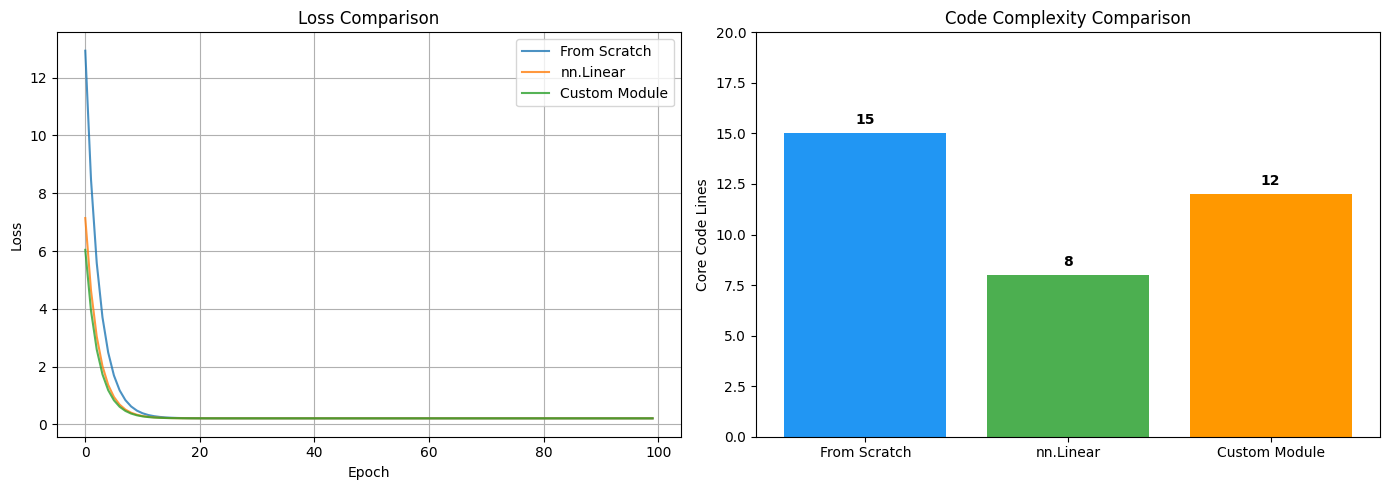

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线对比
axes[0].plot(losses, label='From Scratch', alpha=0.8)
axes[0].plot(nn_losses, label='nn.Linear', alpha=0.8)
axes[0].plot(custom_losses, label='Custom Module', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Comparison')
axes[0].legend()
axes[0].grid(True)

# 代码量对比
methods = ['From Scratch', 'nn.Linear', 'Custom Module']
code_lines = [15, 8, 12]  # 核心训练代码行数
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = axes[1].bar(methods, code_lines, color=colors)
axes[1].set_ylabel('Core Code Lines')
axes[1].set_title('Code Complexity Comparison')
for bar, lines in zip(bars, code_lines):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(lines), ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

## 多维线性回归

In [14]:
# 多维特征：y = 2*x1 + 3*x2 - 1*x3 + 0.5
torch.manual_seed(42)
n_features = 3
n_samples = 500

true_w = torch.tensor([2.0, 3.0, -1.0])
true_b = 0.5

X_multi = torch.randn(n_samples, n_features)
y_multi = X_multi @ true_w + true_b + 0.3 * torch.randn(n_samples)
y_multi = y_multi.unsqueeze(1)  # (500,) → (500, 1)

print(f"X shape: {X_multi.shape}, y shape: {y_multi.shape}")
print(f"True weights: {true_w.tolist()}, True bias: {true_b}")

X shape: torch.Size([500, 3]), y shape: torch.Size([500, 1])
True weights: [2.0, 3.0, -1.0], True bias: 0.5


In [15]:
# 用 nn.Module 训练多维线性回归
model_multi = nn.Linear(n_features, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model_multi.parameters(), lr=0.1)

for epoch in range(200):
    y_pred = model_multi(X_multi)
    loss = criterion(y_pred, y_multi)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.item():.6f}")

print(f"\n学习到的权重: {model_multi.weight.data.numpy().flatten()}")
print(f"真实权重:     {true_w.numpy()}")
print(f"学习到的偏置: {model_multi.bias.item():.4f}")
print(f"真实偏置:     {true_b}")

Epoch  50: loss=0.090331
Epoch 100: loss=0.090331
Epoch 150: loss=0.090331
Epoch 200: loss=0.090331

学习到的权重: [ 2.011716   2.9977026 -1.0050474]
真实权重:     [ 2.  3. -1.]
学习到的偏置: 0.4633
真实偏置:     0.5


## Mini-batch 梯度下降

在实际应用中，数据量很大，每次用全部数据计算梯度太慢。
Mini-batch 方式每次只用一小批数据，训练更快且更稳定。

PyTorch 的 `DataLoader` 可以方便地实现 Mini-batch。

In [16]:
from torch.utils.data import TensorDataset, DataLoader

# 创建数据集和数据加载器
dataset = TensorDataset(X_multi, y_multi)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"总样本数: {len(dataset)}")
print(f"批次数: {len(dataloader)}")
print(f"每批大小: 32")

# 查看一个 batch
X_batch, y_batch = next(iter(dataloader))
print(f"\n一个 batch 的形状: X={X_batch.shape}, y={y_batch.shape}")

总样本数: 500
批次数: 16
每批大小: 32

一个 batch 的形状: X=torch.Size([32, 3]), y=torch.Size([32, 1])


In [17]:
# 使用 DataLoader 训练
model_batch = nn.Linear(n_features, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model_batch.parameters(), lr=0.05)

n_epochs = 50

for epoch in range(n_epochs):
    epoch_loss = 0.0
    n_batches = 0
    
    for X_batch, y_batch in dataloader:
        y_pred = model_batch(X_batch)
        loss = criterion(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: avg_loss={avg_loss:.6f}")

print(f"\n学习到的权重: {model_batch.weight.data.numpy().flatten()}")
print(f"真实权重:     {true_w.numpy()}")

Epoch  10: avg_loss=0.090848
Epoch  20: avg_loss=0.092504
Epoch  30: avg_loss=0.091734
Epoch  40: avg_loss=0.090006
Epoch  50: avg_loss=0.091382

学习到的权重: [ 2.0018487  2.998328  -0.9955156]
真实权重:     [ 2.  3. -1.]


## 不同优化器对比

In [18]:
# 对比 SGD vs Adam
torch.manual_seed(42)

optimizers_config = {
    'SGD (lr=0.1)': optim.SGD,
    'SGD+Momentum (lr=0.1)': lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9),
    'Adam (lr=0.05)': optim.Adam,
}

results = {}

for name, opt_class in optimizers_config.items():
    torch.manual_seed(42)
    model = nn.Linear(1, 1)
    criterion = nn.MSELoss()
    lr = 0.1 if 'SGD' in name and 'Momentum' not in name else (0.1 if 'Momentum' in name else 0.05)
    optimizer = opt_class(model.parameters(), lr=lr) if not callable(opt_class) else opt_class(model.parameters(), lr)
    
    losses = []
    for epoch in range(50):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    results[name] = losses
    print(f"{name}: 最终 loss={losses[-1]:.6f}, w={model.weight.item():.4f}, b={model.bias.item():.4f}")

print(f"\n真实参数: w={true_w}, b={true_b}")

SGD (lr=0.1): 最终 loss=0.207402, w=2.0241, b=1.0646
SGD+Momentum (lr=0.1): 最终 loss=0.213068, w=2.0790, b=1.0329
Adam (lr=0.05): 最终 loss=0.217220, w=2.1210, b=1.0495

真实参数: w=tensor([ 2.,  3., -1.]), b=0.5


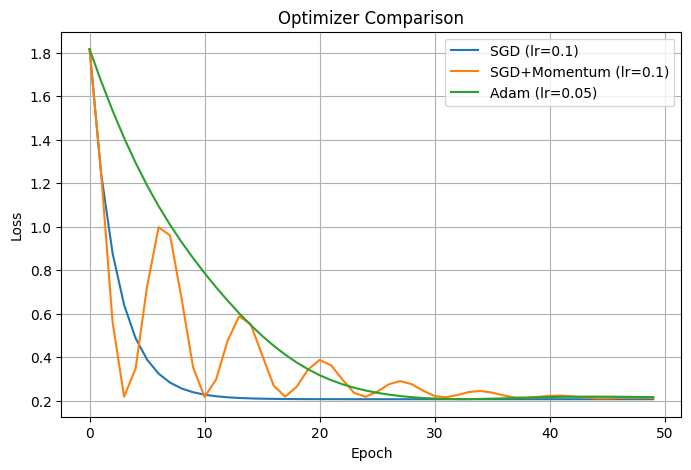

In [19]:
# 可视化优化器对比
plt.figure(figsize=(8, 5))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimizer Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 模型保存与加载

In [20]:
# 保存模型参数
torch.save(model_custom.state_dict(), 'linear_model.pth')
print("模型已保存到 linear_model.pth")

# 加载模型参数
new_model = LinearRegressionModel()
new_model.load_state_dict(torch.load('linear_model.pth', weights_only=True))
new_model.eval()  # 切换到评估模式

print(f"加载的模型参数: w={new_model.linear.weight.item():.4f}, b={new_model.linear.bias.item():.4f}")

# 验证预测结果一致
test_x = torch.tensor([[1.5]])
with torch.no_grad():
    pred_original = model_custom(test_x)
    pred_loaded = new_model(test_x)
print(f"\n原始模型预测: {pred_original.item():.4f}")
print(f"加载模型预测: {pred_loaded.item():.4f}")
print(f"两者一致: {torch.allclose(pred_original, pred_loaded)}")

模型已保存到 linear_model.pth
加载的模型参数: w=2.0242, b=1.0646

原始模型预测: 4.1009
加载模型预测: 4.1009
两者一致: True


In [21]:
import os
os.remove('linear_model.pth')
print("临时文件已清理")

临时文件已清理


---
## 📝 第三课总结

### 三种实现方式对比

| 方式 | 优点 | 缺点 | 适用场景 |
|------|------|------|----------|
| 从零实现 | 理解底层原理 | 代码繁琐 | 学习、理解原理 |
| nn.Linear | 简洁快速 | 灵活性有限 | 简单任务 |
| 自定义 Module | 灵活、可扩展 | 代码稍多 | 实际项目 |

### PyTorch 训练标准流程
```python
# 1. 准备数据
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. 定义模型、损失、优化器
model = MyModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 3. 训练循环
for epoch in range(epochs):
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch)       # 前向传播
        loss = criterion(y_pred, y_batch)  # 计算损失
        optimizer.zero_grad()         # 清零梯度
        loss.backward()               # 反向传播
        optimizer.step()              # 更新参数
```

### 关键概念
- **nn.Module**: 所有模型的基类，管理参数和层
- **forward()**: 定义前向传播，必须实现
- **optimizer.zero_grad()**: 清零梯度（替代手动 zero_()）
- **optimizer.step()**: 更新参数（替代手动 w -= lr * grad）
- **model.eval()**: 切换到评估模式
- **torch.no_grad()**: 推理时关闭梯度计算
- **state_dict()**: 获取/加载模型参数